In [58]:
#All Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

### Part B: Dataset Understanding & Preparation

<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Admin\AppData\Local\Temp\ipykernel_24012\1319264129.py:2: SyntaxWarning: invalid escape sequence '\S'
  data = pd.read_csv('D:\Supervised Learning\Pr.1\RealEstate_HousePrice_Dataset_4200 - RealEstate_HousePrice_Dataset_4200.csv.csv')


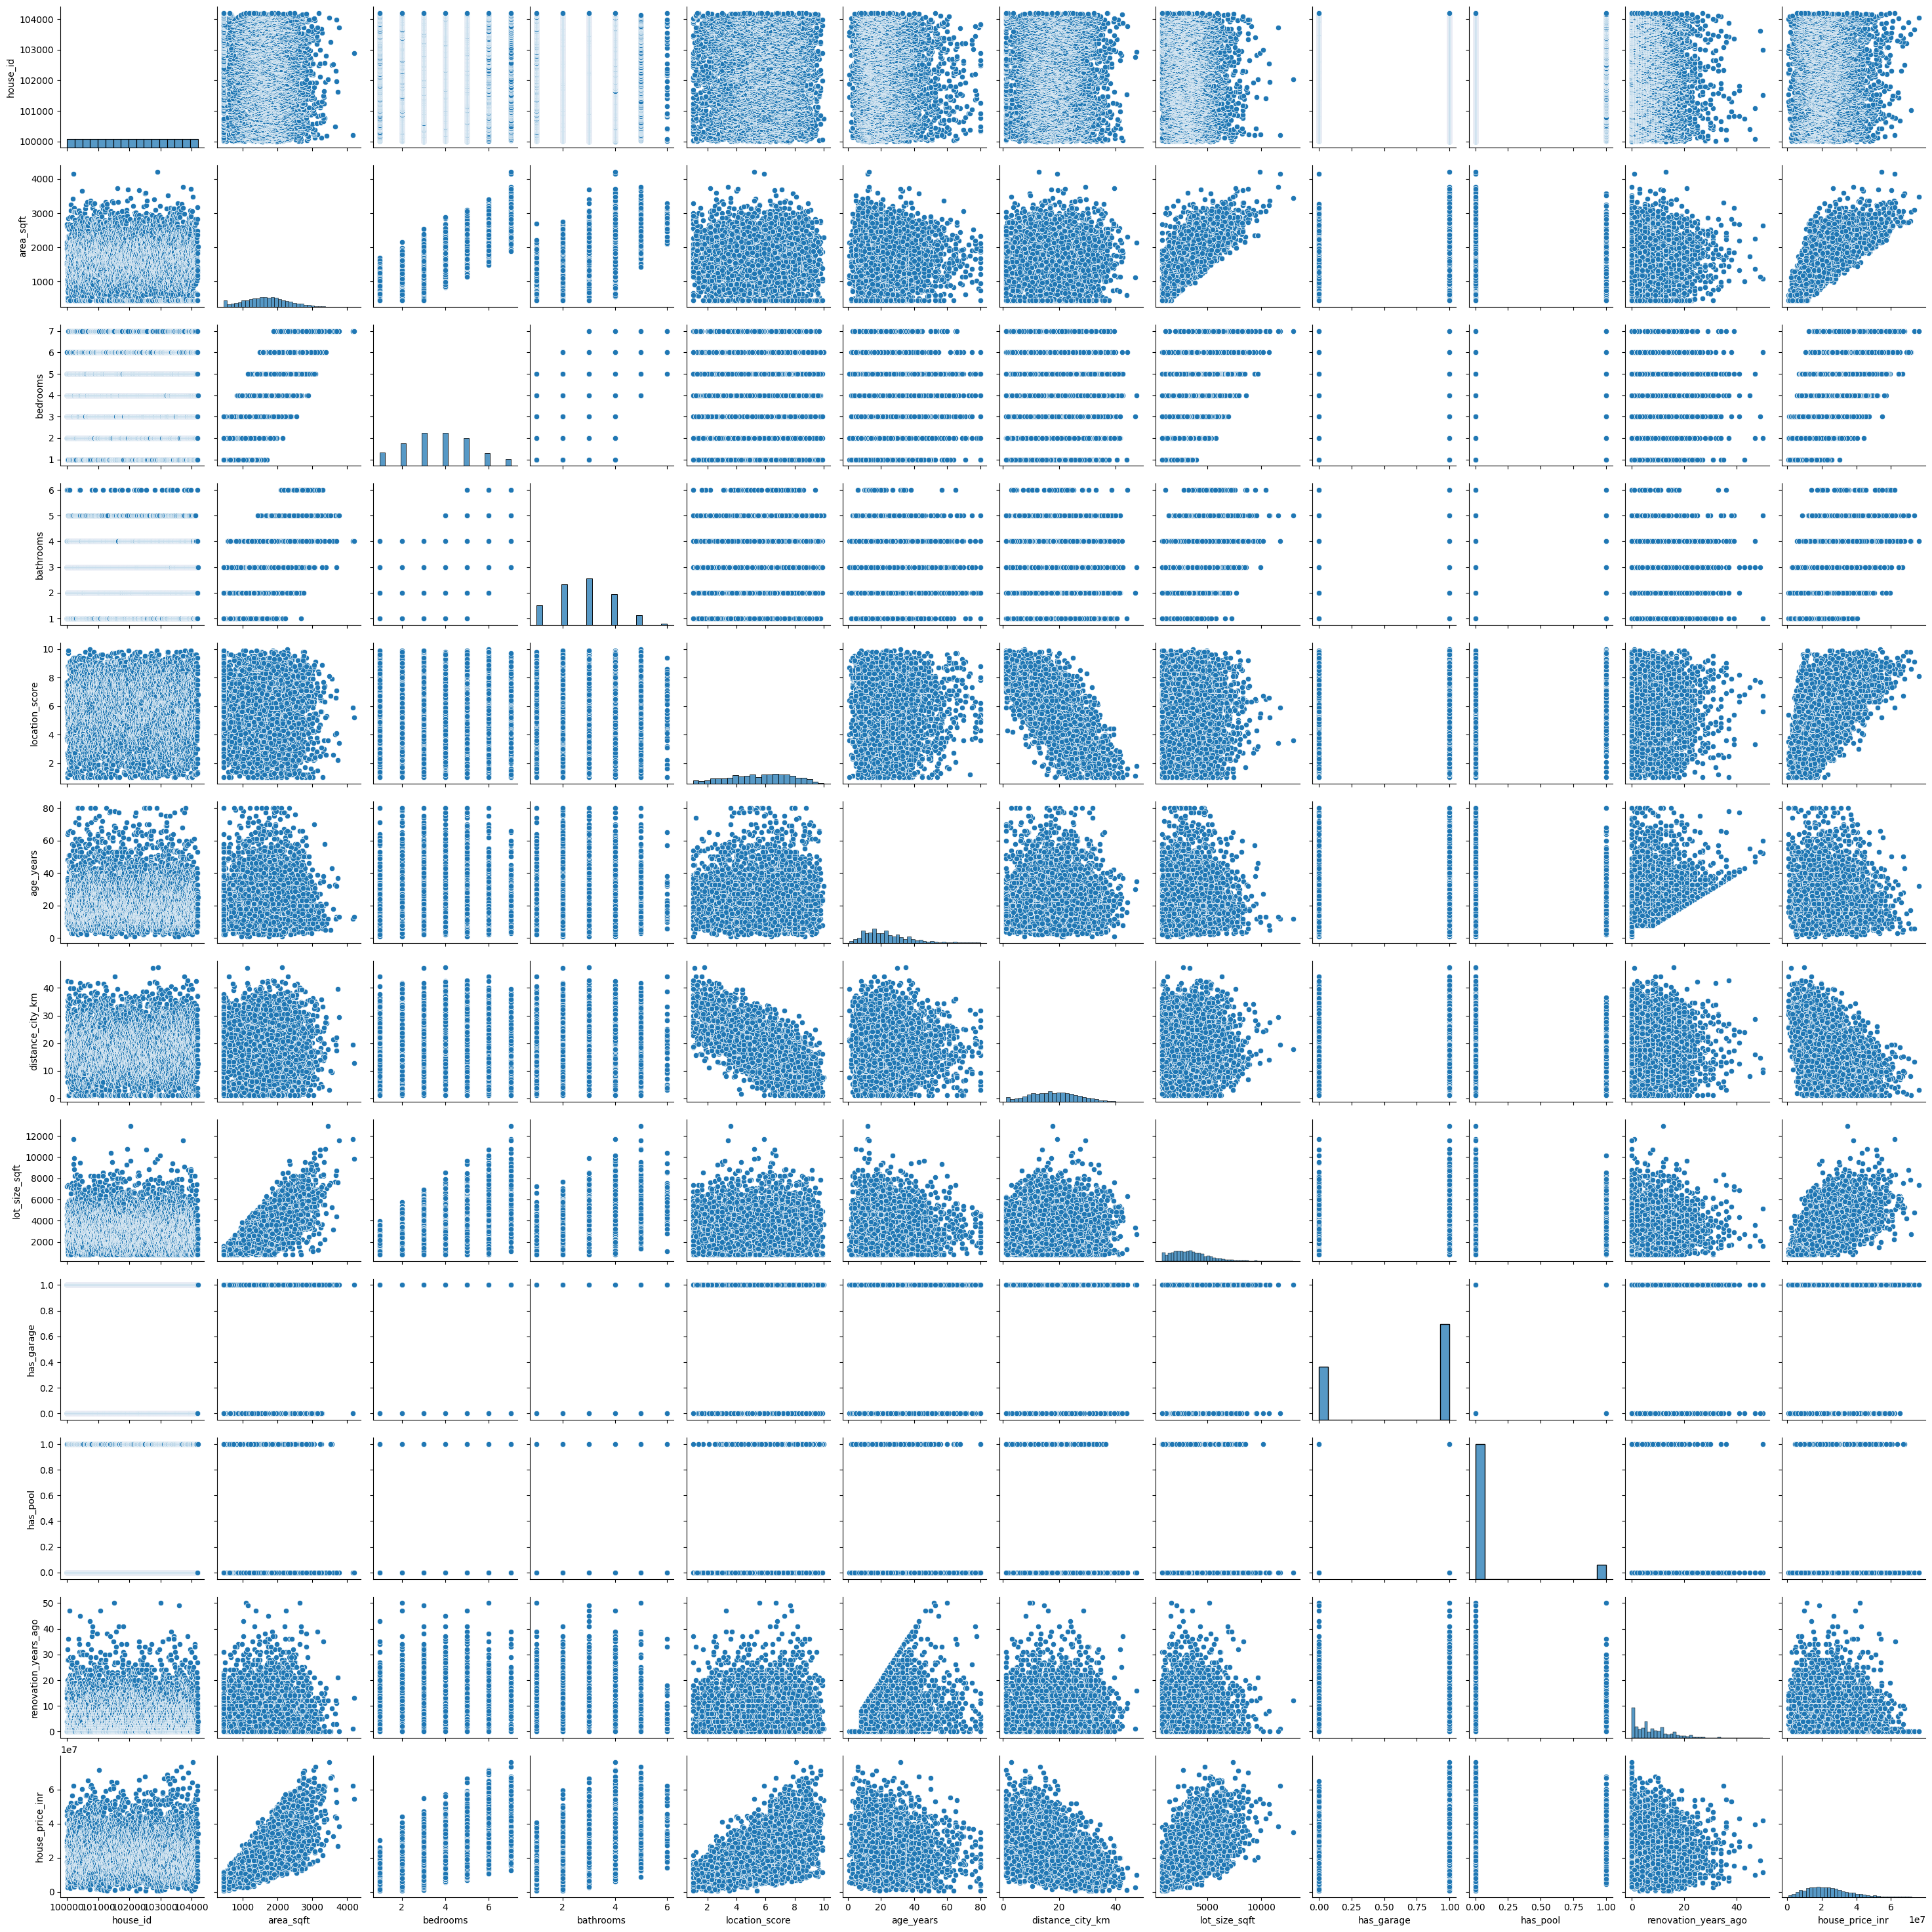

In [59]:
#Dataset loading
data = pd.read_csv('D:\Supervised Learning\Pr.1\RealEstate_HousePrice_Dataset_4200 - RealEstate_HousePrice_Dataset_4200.csv.csv')
data.head()

#Identify independent and dependent variables.
x=data.drop(['house_id', 'house_price_inr'], axis=1)
y=data['house_price_inr']

#Visualize relationships between features and target variable.
visualize=sns.pairplot(data)

#Split the dataset into training and testing sets.
x_train, x_test, y_train, y_test = sk.model_selection.train_test_split(x,y, test_size=0.2, random_state=42)

### Part C: Simple Linear Regression

Linear Regression Coefficients: [14788.30611131], Intercept: -1163519.1764186025


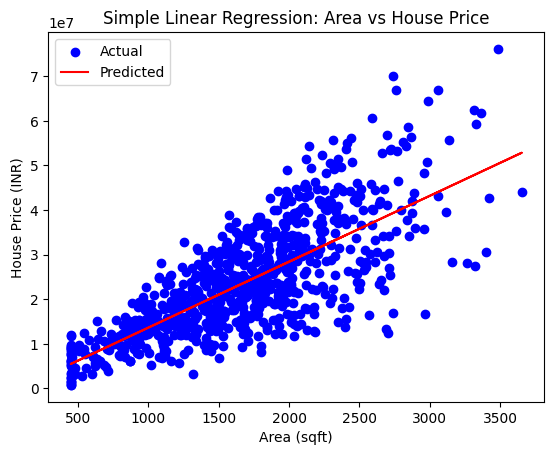

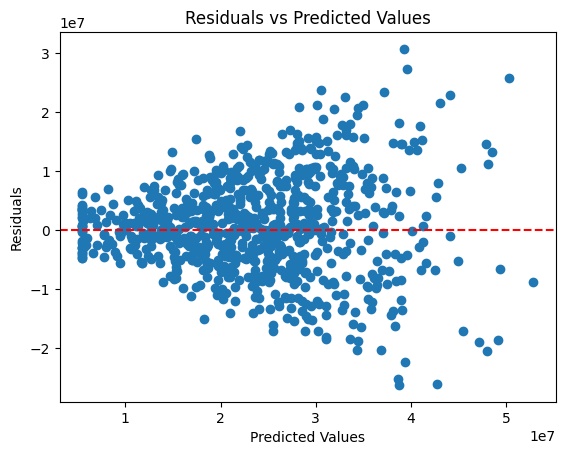

In [60]:
#Implement Simple Linear Regression using one feature (e.g., House Area).
linear_model=sk.linear_model.LinearRegression()
linear_model.fit(x_train[['area_sqft']], y_train)
y_pred_linear=linear_model.predict(x_test[['area_sqft']])
print(f"Linear Regression Coefficients: {linear_model.coef_}, Intercept: {linear_model.intercept_}")

#Plot the regression line and interpret the slope and intercept.
plt.scatter(x_test['area_sqft'], y_test, color='blue', label='Actual')
plt.plot(x_test['area_sqft'], y_pred_linear, color='red', label='Predicted')
plt.xlabel('Area (sqft)')
plt.ylabel('House Price (INR)')
plt.title('Simple Linear Regression: Area vs House Price')
plt.legend()
plt.show()

#Validate linear regression assumptions using plots and observations.
residuals = y_test - y_pred_linear
plt.scatter(y_pred_linear, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()

### Part D: Model Evaluation Metrics

In [61]:
'''Evaluate the Simple Linear Regression model using:
• Mean Squared Error (MSE)
• Mean Absolute Error (MAE)
• Root Mean Squared Error (RMSE)
• R2 Score
• Adjusted R2 Score'''

mse=sk.metrics.mean_squared_error(y_test, y_pred_linear)
mae=sk.metrics.mean_absolute_error(y_test, y_pred_linear)
rmse=sk.metrics.root_mean_squared_error(y_test, y_pred_linear)
r2=sk.metrics.r2_score(y_test, y_pred_linear)
n=len(y_test)
p=1
adjusted_r2=1-(1-r2)*(n-1)/(n-p-1)
print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'Root Mean Squared Error: {rmse}')
print(f'R2 Score: {r2}')
print(f'Adjusted R2 Score: {adjusted_r2}')


Mean Squared Error: 66989260021849.47
Mean Absolute Error: 6294593.696131912
Root Mean Squared Error: 8184696.696997969
R2 Score: 0.5625199587991578
Adjusted R2 Score: 0.5619979062440257


### Part E: Multiple Linear Regression

In [62]:
#MLR Model
mlr=sk.linear_model.LinearRegression()
mlr.fit(x_train, y_train)

#prediction
y_pred_mlr=mlr.predict(x_test)    
print(f"Multiple Linear Regression Coefficients: {mlr.coef_}, Intercept: {mlr.intercept_}\n")

mse_mlr = sk.metrics.mean_squared_error(y_test, y_pred_mlr)
mae_mlr = sk.metrics.mean_absolute_error(y_test, y_pred_mlr)
rmse_mlr = sk.metrics.root_mean_squared_error(y_test, y_pred_mlr)
r2_mlr = sk.metrics.r2_score(y_test, y_pred_mlr)

n = len(y_test)
p = x_test.shape[1] 
adjusted_r2_mlr = 1 - ((1 - r2_mlr) * (n - 1) / (n - p - 1))

print("Multiple Linear Regression Results")
print(f"MSE: {mse_mlr}")
print(f"MAE: {mae_mlr}")
print(f"RMSE: {rmse_mlr}")
print(f"R² Score: {r2_mlr}")
print(f"Adjusted R² Score: {adjusted_r2_mlr}")

Multiple Linear Regression Coefficients: [ 1.37959436e+04  1.97643105e+05  1.85944541e+05  3.07317350e+06
 -6.56092445e+04 -9.89651574e+04  1.03505816e+02  9.39243608e+04
  4.55290229e+05 -2.14359126e+04], Intercept: -14766762.745674264

Multiple Linear Regression Results
MSE: 12592918884127.742
MAE: 2604991.406155695
RMSE: 3548650.290480557
R² Score: 0.917760687750989
Adjusted R² Score: 0.916768657446417


In [63]:
#Compare its performance with Simple Linear Regression.
comparison_df = pd.DataFrame({'Metric': ['MSE', 'MAE', 'RMSE', 'R²', 'Adjusted R²'],'Simple Linear Regression': [
        mse,
        mae,
        rmse,
        r2,
        adjusted_r2
    ],
    'Multiple Linear Regression': [
        mse_mlr,
        mae_mlr,
        rmse_mlr,
        r2_mlr,
        adjusted_r2_mlr
    ]
})

print(comparison_df)

        Metric  Simple Linear Regression  Multiple Linear Regression
0          MSE              6.698926e+13                1.259292e+13
1          MAE              6.294594e+06                2.604991e+06
2         RMSE              8.184697e+06                3.548650e+06
3           R²              5.625200e-01                9.177607e-01
4  Adjusted R²              5.619979e-01                9.167687e-01


Multiple Linear Regression performed better than Simple Linear Regression as it uses all relevant features instead of only house area. It achieved lower prediction errors and a higher R² score, resulting in more accurate house price predictions.

### Part F: Polynomial Regression

In [69]:
#Implement Polynomial Regression (degree 2 or 3).
poly = sk.preprocessing.PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(x_train[['area_sqft']])
X_test_poly = poly.transform(x_test[['area_sqft']])

poly_model = sk.linear_model.LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

mse_poly = sk.metrics.mean_squared_error(y_test, y_pred_poly)
mae_poly = sk.metrics.mean_absolute_error(y_test, y_pred_poly)
rmse_poly = sk.metrics.root_mean_squared_error(y_test, y_pred_poly)
r2_poly = sk.metrics.r2_score(y_test, y_pred_poly)

n = len(y_test)
p = X_test_poly.shape[1] - 1

adjusted_r2_poly = 1 - ((1 - r2_poly) * (n - 1) / (n - p - 1))

print("MSE:", mse_poly)
print("MAE:", mae_poly)
print("RMSE:", rmse_poly)
print("R²:", r2_poly)
print("Adjusted R²:", adjusted_r2_poly)

MSE: 66962947122198.21
MAE: 6292394.5612817025
RMSE: 8183089.094113434
R²: 0.5626917978136475
Adjusted R²: 0.5616468558729394


In [70]:
#Compare linear us polynomial regression visually and numerically.
comparison_df_poly = pd.DataFrame({'Metric': ['MSE', 'MAE', 'RMSE', 'R²', 'Adjusted R²'],'Simple Linear Regression': [
        mse,
        mae,
        rmse,
        r2,
        adjusted_r2
    ],
    'Multiple Linear Regression': [
        mse_poly,
        mae_poly,
        rmse_poly,
        r2_poly,
        adjusted_r2_poly
    ]
})

print(comparison_df_poly)

        Metric  Simple Linear Regression  Multiple Linear Regression
0          MSE              6.698926e+13                6.696295e+13
1          MAE              6.294594e+06                6.292395e+06
2         RMSE              8.184697e+06                8.183089e+06
3           R²              5.625200e-01                5.626918e-01
4  Adjusted R²              5.619979e-01                5.616469e-01


### Part G: Gradient Descent Optimization

In [79]:
#Batch Gradient Descent for Linear Regression
x_train_bgd = x_train[['area_sqft']].values
y_train_bgd = y_train.values

b0 = 0
b1 = 0
lr=0.01
epochs=1000
n=len(x_train_bgd)

for i in range(epochs):
    y_pred_bgd = b0 + b1 * x_train_bgd
    error = y_pred_bgd-y_train_bgd

    grad_b0 = (1/n) * np.sum(error)
    grad_b1 = (1/n) * np.sum(error * x_train_bgd)

    b0 = b0 - lr * grad_b0
    b1 = b1 - lr * grad_b1

print("Intercept:", b0)
print("Slope:", b1)

In [82]:
#Stochastic Gradient Descent for Linear Regression
b0_sgd = 0
b1_sgd = 0

lr_sgd = 0.00000001
epochs_sgd = 50

for epoch in range(epochs_sgd):

    for i in range(len(x_train_bgd)):

        xi = x_train_bgd[i]
        yi = y_train_bgd[i]

        y_pred = b0_sgd + b1_sgd * xi

        error_sgd = yi - y_pred

        grad_b0_sgd = -2 * error_sgd
        grad_b1_sgd = -2 * xi * error_sgd

        b0_sgd = b0_sgd - lr_sgd * grad_b0_sgd
        b1_sgd = b1_sgd - lr_sgd * grad_b1_sgd

print("Intercept:", b0_sgd)
print("Slope:", b1_sgd)

Intercept: [-437.81368162]
Slope: [15527.93869877]


In [86]:
#Mini-Batch Gradient Descent for Linear Regression
batch_size = 32
b0_mbgd = 0
b1_mbgd = 0

lr_mbgd = 0.00000001
epochs_mbgd = 100

batch_size = 32

for epoch in range(epochs_mbgd):

    for i in range(0, len(x_train_bgd), batch_size):

        X_batch = x_train_bgd[i:i+batch_size]
        y_batch = y_train_bgd[i:i+batch_size]

        y_pred_mbgd = b0_mbgd + b1_mbgd * X_batch

        error_mbgd = y_batch - y_pred_mbgd

        grad_b0_mbgd = (-2/len(X_batch)) * np.sum(error_mbgd)
        grad_b1_mbgd = (-2/len(X_batch)) * np.sum(X_batch * error_mbgd)

        b0_mbgd = b0_mbgd - lr_mbgd * grad_b0_mbgd
        b1_mbgd = b1_mbgd - lr_mbgd * grad_b1_mbgd

print("Intercept:", b0_mbgd)
print("Slope:", b1_mbgd)

Intercept: 29408.46329537117
Slope: -5103.661186268109


Batch Gradient Descent was the most stable but required more computation time. SGD converged faster but showed fluctuations during training. Mini-Batch Gradient Descent provided a good balance between speed and stability, making it the most practical approach.

### Part H: Bias-Variance & Model Diagnostics

In [93]:
#SLR
slr_train_r2 = linear_model.score(x_train[['area_sqft']], y_train)
slr_test_r2 = linear_model.score(x_test[['area_sqft']], y_test)

print("SLR Train R²:", slr_train_r2)
print("SLR Test R²:", slr_test_r2,"\n")

#MLR
mlr_train_r2 = mlr.score(x_train, y_train)
mlr_test_r2 = mlr.score(x_test, y_test)

print("MLR Train R²:", mlr_train_r2)
print("MLR Test R²:", mlr_test_r2,"\n")

#Poly
poly_train_r2 = poly_model.score(X_train_poly, y_train)
poly_test_r2 = poly_model.score(X_test_poly, y_test)

print("Polynomial Train R²:", poly_train_r2)
print("Polynomial Test R²:", poly_test_r2,"\n")

comparison = pd.DataFrame({
    "Model": ["Simple LR", "Multiple LR", "Polynomial"],
    "Train R²": [slr_train_r2, mlr_train_r2, poly_train_r2],
    "Test R²": [slr_test_r2, mlr_test_r2, poly_test_r2]
})

print(comparison)

SLR Train R²: 0.5723074839148459
SLR Test R²: 0.5625199587991578 

MLR Train R²: 0.9247216651865339
MLR Test R²: 0.917760687750989 

Polynomial Train R²: 0.5724674245504779
Polynomial Test R²: 0.5626917978136475 

         Model  Train R²   Test R²
0    Simple LR  0.572307  0.562520
1  Multiple LR  0.924722  0.917761
2   Polynomial  0.572467  0.562692


1. SLR
- the model r2 values is low indicating high bias and underfitting 

2. MLR 
- the model r2 is high and this shows the good balance between bias and variance 

3. Poly
- the model r2 is same as SLR indicating that polynomial doesn't effect much in this

4. Discuss the Bias–Variance Trade-off

- The results show that increasing model complexity can reduce bias, but excessive complexity may increase variance. In this dataset, Multiple Linear Regression achieved the best balance by providing high accuracy while maintaining similar train and test performance.

5. Recommend the Best Model

- Multiple Linear Regression is the recommended model because it achieved the highest training and 

### Part I: Final Analysis & Reporting

1. Summarize which model performed best and why.

- Multiple Linear Regression performed the best among all models. It achieved the highest R² score and the lowest prediction errors. 

2. Discuss the impact of Gradient Descent on optimization.

- Gradient Descent helped optimize the model parameters by minimizing the prediction error. It improved the model's learning process through iterative updates of the coefficients until a lower cost was achieved.

3. Provide practical business interpretation.

- House area, number of bedrooms, bathrooms, location score, and property characteristics have a significant impact on house prices. Real estate companies can use Multiple Linear Regression to estimate property values more accurately and support pricing decisions.